# 01 Exploratory Data Analysis

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_functions.merge_crmls_dataset_unfiltered import merge_raw_crmls_data_unfiltered

Raw Data Loading

In [2]:
listing_df, sold_df = merge_raw_crmls_data_unfiltered(write_csv=False)
listing_df.head()

,source_file,file_period,sort_date,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName__dup2,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress__dup2
0,CRMLSListing202401.csv,202401,2024-01-01,1399990.0,1043760653,joe@porchlightsocal.com,2024-03-15,1270000.0,Joseph,Vahedi,...,2,,2.0,Vista Unified,92083,eXp Realty of Southern CA,252.0,9897.0,,123 Flores Lane
1,CRMLSListing202401.csv,202401,2024-01-01,8500.0,1052705926,champ@thereoco.com,2024-01-03,8500.0,Horace,Davenport,...,,False,,,90292,Keller Williams Larchmont,,5266.0,,952 PRINCETON Drive
2,CRMLSListing202401.csv,202401,2024-01-01,789900.0,1053093534,kiva@kivakendrick.com,2024-02-26,800000.0,Kiva,Kendrick,...,,False,2.0,Los Angeles Unified,90746,R & R Realty,,5070.0,,19922 Enslow Drive
3,CRMLSListing202401.csv,202401,2024-01-01,1050000.0,1054014526,sarah.pearce@cbrealty.com,,,Sarah,Pearce,...,,False,,,92262,,,10019.0,,2030 E Acacia Road
4,CRMLSListing202401.csv,202401,2024-01-01,1250000.0,1054022382,mricks@mypsrealtor.com,2024-02-26,1199000.0,Michael,Ricks,...,,False,2.0,,92262,BHG Desert Lifestyle Properties,,10454.0,,1695 E Buena Vista Drive


In [3]:
print("Listing shape:", listing_df.shape)
print("Sold shape:", sold_df.shape)

Listing shape: (852963, 87)
Sold shape: (591733, 87)


key numeric columns:

In [5]:
numeric_cols = [
    "ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea",
    "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger",
    "DaysOnMarket", "YearBuilt"
]

In [12]:
listing_df[numeric_cols].dtypes

ClosePrice               float64
ListPrice                float64
OriginalListPrice        float64
LivingArea               float64
LotSizeAcres             float64
BedroomsTotal            float64
BathroomsTotalInteger    float64
DaysOnMarket               int64
YearBuilt                float64
dtype: object

In [13]:
sold_df[numeric_cols].dtypes

ClosePrice               object
ListPrice                object
OriginalListPrice        object
LivingArea               object
LotSizeAcres             object
BedroomsTotal            object
BathroomsTotalInteger    object
DaysOnMarket             object
YearBuilt                object
dtype: object

In [14]:
sold_df["ClosePrice"] = pd.to_numeric(sold_df["ClosePrice"], errors="coerce")
sold_df["ListPrice"] = pd.to_numeric(sold_df["ListPrice"], errors="coerce")
sold_df["OriginalListPrice"] = pd.to_numeric(sold_df["OriginalListPrice"], errors="coerce")
sold_df["LivingArea"] = pd.to_numeric(sold_df["LivingArea"], errors="coerce")
sold_df["BedroomsTotal"] = pd.to_numeric(sold_df["BedroomsTotal"], errors="coerce")
sold_df["BathroomsTotalInteger"] = pd.to_numeric(sold_df["BathroomsTotalInteger"], errors="coerce")
sold_df["DaysOnMarket"] = pd.to_numeric(sold_df["DaysOnMarket"], errors="coerce")
sold_df["YearBuilt"] = pd.to_numeric(sold_df["YearBuilt"], errors="coerce")
listing_df[numeric_cols].dtypes

ClosePrice               float64
ListPrice                float64
OriginalListPrice        float64
LivingArea               float64
LotSizeAcres             float64
BedroomsTotal            float64
BathroomsTotalInteger    float64
DaysOnMarket               int64
YearBuilt                float64
dtype: object

Numeric Distribution for Listing data

In [15]:
for col in numeric_cols:
    if col in listing_df.columns:
        listing_df[col] = pd.to_numeric(listing_df[col], errors="coerce")
    if col in listing_df.columns:
        listing_df[col] = pd.to_numeric(listing_df[col], errors="coerce")

date_cols = ["CloseDate", "PurchaseContractDate", "ListingContractDate", "ContractStatusChangeDate"]

for col in date_cols:
    if col in sold_df.columns:
        sold_df[col] = pd.to_datetime(sold_df[col], errors="coerce")

### 1. Residential vs other property type share

Listing Data Check:

In [16]:
listing_property_counts = listing_df["PropertyType"].value_counts(dropna=False)
listing_total = listing_property_counts.sum()

listing_residential_count = listing_property_counts.get("Residential", 0)
listing_other_count = listing_total - listing_residential_count

listing_property_share = pd.DataFrame({
    "group": ["Residential", "Other"],
    "count": [listing_residential_count, listing_other_count],
    "percent": [
        listing_residential_count / listing_total * 100,
        listing_other_count / listing_total * 100
    ]
})

print("Listing property type share:")
display(listing_property_share)

print("Full listing property type breakdown:")
display((listing_property_counts / listing_total * 100).round(2).rename("percent").reset_index())

Listing property type share:


,group,count,percent
0,Residential,540183,63.33018
1,Other,312780,36.66982


Full listing property type breakdown:


,PropertyType,percent
0,Residential,63.33
1,ResidentialLease,20.87
2,Land,6.61
3,ResidentialIncome,3.71
4,ManufacturedInPark,2.88
5,CommercialSale,1.37
6,CommercialLease,0.91
7,BusinessOpportunity,0.32


Sold Data Check:

In [17]:
sold_property_counts = sold_df["PropertyType"].value_counts(dropna=False)
sold_total = sold_property_counts.sum()

sold_residential_count = sold_property_counts.get("Residential", 0)
sold_other_count = sold_total - sold_residential_count

sold_property_share = pd.DataFrame({
    "group": ["Residential", "Other"],
    "count": [sold_residential_count, sold_other_count],
    "percent": [
        sold_residential_count / sold_total * 100,
        sold_other_count / sold_total * 100
    ]
})

print("Sold property type share:")
display(sold_property_share)

print("Full sold property type breakdown:")
display((sold_property_counts / sold_total * 100).round(2).rename("percent").reset_index())

Sold property type share:


,group,count,percent
0,Residential,397603,67.192974
1,Other,194130,32.807026


Full sold property type breakdown:


,PropertyType,percent
0,Residential,67.19
1,ResidentialLease,22.92
2,Land,3.27
3,ManufacturedInPark,2.72
4,ResidentialIncome,2.68
5,CommercialSale,0.63
6,CommercialLease,0.52
7,BusinessOpportunity,0.07


### 2. Create a Residential sold subset for home-sale questions

In [18]:
sold_residential = sold_df[sold_df["PropertyType"] == "Residential"].copy()

print("Residential sold shape:", sold_residential.shape)

Residential sold shape: (397603, 87)


### 3. Median and average close prices

In [19]:
close_price_summary = pd.DataFrame({
    "metric": ["median_close_price", "average_close_price"],
    "value": [
        sold_residential["ClosePrice"].median(),
        sold_residential["ClosePrice"].mean()
    ]
})

display(close_price_summary)

,metric,value
0,median_close_price,8.200000e+05
1,average_close_price,1.185616e+06


### 4. Days on Market distribution

In [20]:
dom = sold_residential["DaysOnMarket"].dropna()

dom_summary = pd.DataFrame({
    "statistic": [
        "count", "mean", "median", "min",
        "p25", "p75", "p95", "p99", "max",
        "negative_count"
    ],
    "value": [
        dom.shape[0],
        dom.mean(),
        dom.median(),
        dom.min(),
        dom.quantile(0.25),
        dom.quantile(0.75),
        dom.quantile(0.95),
        dom.quantile(0.99),
        dom.max(),
        (dom < 0).sum()
    ]
})

display(dom_summary)

,statistic,value
0,count,397603.000000
1,mean,37.336788
2,median,19.000000
3,min,-288.000000
4,p25,8.000000
5,p75,48.000000
6,p95,131.000000
7,p99,229.000000
8,max,12430.000000
9,negative_count,46.000000


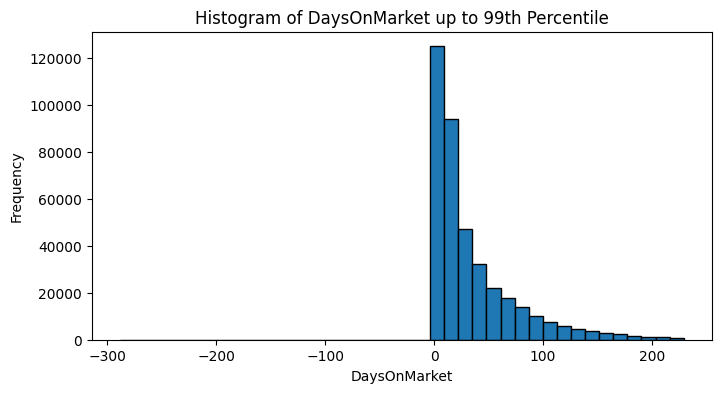

In [22]:
dom_99 = dom[dom <= dom.quantile(0.99)]

plt.figure(figsize=(8, 4))
plt.hist(dom_99, bins=40, edgecolor="black")
plt.title("Histogram of DaysOnMarket up to 99th Percentile")
plt.xlabel("DaysOnMarket")
plt.ylabel("Frequency")
plt.show()

### 5. Percentage sold above vs below list price

In [26]:
price_compare = sold_residential[
    sold_residential["ClosePrice"].notna() & sold_residential["ListPrice"].notna()
].copy()

price_compare["price_diff"] = price_compare["ClosePrice"] - price_compare["ListPrice"]

above_count = (price_compare["price_diff"] > 0).sum()
below_count = (price_compare["price_diff"] < 0).sum()
equal_count = (price_compare["price_diff"] == 0).sum()
total_count = price_compare.shape[0]

sale_to_list_summary = pd.DataFrame({
    "group": ["Above list", "Below list", "At list"],
    "count": [above_count, below_count, equal_count],
    "percent": [
        above_count / total_count * 100,
        below_count / total_count * 100,
        equal_count / total_count * 100
    ]
})

display(sale_to_list_summary)

,group,count,percent
0,Above list,159483,40.111318
1,Below list,169158,42.544662
2,At list,68960,17.344021


### 6. Date consistency checks

In [27]:
date_issue_summary = pd.DataFrame({
    "check": [
        "CloseDate before ListingContractDate",
        "CloseDate before PurchaseContractDate",
        "PurchaseContractDate before ListingContractDate"
    ],
    "issue_count": [
        (
            (sold_residential["CloseDate"] < sold_residential["ListingContractDate"]) &
            sold_residential["CloseDate"].notna() &
            sold_residential["ListingContractDate"].notna()
        ).sum(),
        (
            (sold_residential["CloseDate"] < sold_residential["PurchaseContractDate"]) &
            sold_residential["CloseDate"].notna() &
            sold_residential["PurchaseContractDate"].notna()
        ).sum(),
        (
            (sold_residential["PurchaseContractDate"] < sold_residential["ListingContractDate"]) &
            sold_residential["PurchaseContractDate"].notna() &
            sold_residential["ListingContractDate"].notna()
        ).sum()
    ]
})

display(date_issue_summary)

,check,issue_count
0,CloseDate before ListingContractDate,58
1,CloseDate before PurchaseContractDate,240
2,PurchaseContractDate before ListingContractDate,261
